In [1]:
import pandas as pd
import numpy as np
import glob 
import duckdb
import os
os.chdir("..")
import plotting_helpers
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from trebl_tools import plotting

# Calculating activity per BC combo

In [2]:
# Loading in step 1 map

con = duckdb.connect("../../duckdb/GCN4_activity_scores.db")

con.execute("""
CREATE TABLE step1_map AS
SELECT DISTINCT
    AD,
    AD_BC,
    RPTR_BC
FROM read_csv_auto('../../output/GCN4_pipeline/step1.csv');
SELECT * FROM step1_map LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC
0,ATTGCTGCTCCAGTTCCAGCTGTTAAAGCTGAACCACCAGTTTCTT...,GCTAGCCCCGA,GCACTATAACACTT
1,GTTACTTCTGAAGTTGCTGATAGAAGATGTAAATCTACTTCTGATT...,AGTGGTTCCTA,CTATCCTAGCGATA
2,CCAGAAGAAGAATTGGAAGTTTCTGAAGCTTTGAGAACTTCTGCTT...,ACCTCTAGGGA,CCCTGAGTACCTTG
3,GCATTTGTTTCTGGTGCTGGTGAAGATCCAATCTTGGCTTTGGATG...,GGGCTGTTATT,TTAAGACTGAATAG
4,TATAATGAATCTCCAGACTTTAATGATGGTTATGATGTTTCTCCAT...,GGAGCCTTAGA,GGGTTGACGCACTA


# Getting all AD counts

In [3]:
# Reading in simple AD counts

con.execute("""
CREATE TABLE AD_simple AS
SELECT
    AD,
    AD_BC,
    count,
    AD || AD_BC AS gene,
    regexp_extract(filename, 'AD_(\\d+)_', 1)::INT AS rep,
    regexp_extract(filename, 'AD_\\d+_(\\d+)', 1)::INT AS time
FROM read_csv_auto(
    '../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*AD*/*simple*',
    delim='\t',
    filename=true
);
SELECT * FROM AD_simple LIMIT 5;
""").fetchdf()

,AD,AD_BC,count,gene,rep,time
0,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,14966,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,1,0
1,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,9373,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,1,0
2,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,AGTAACAGCTG,9308,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,1,0
3,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,7384,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,1,0
4,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,ATACCGCCAAC,7335,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,1,0


In [6]:
# Reading in directional AD counts

con.execute("""
CREATE TABLE AD_directional AS
SELECT
    gene,
    count,
    regexp_extract(filename, 'AD_(\\d+)_', 1)::INT AS rep,
    regexp_extract(filename, 'AD_\\d+_(\\d+)', 1)::INT AS time
FROM read_csv_auto(
    '../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*AD*/*directional*',
    delim='\t',
    filename=true
);
SELECT * FROM AD_directional LIMIT 5;
""").fetchdf()

,gene,count,rep,time
0,AAAAAAAAAAACAAACCACTTTCCCCAACTGTTTTTGAAGATCCAT...,1,1,0
1,AAAAAAAAAGATAAACCATTGCCACCATTGTTTTTTATGATCCATC...,1,1,0
2,AAAAAAAAATCTGGTACTACTTCTTCTCCACCATCTGGTACTCATT...,1,1,0
3,AAAAAAAAGTCTTCTAAGTTGCCACCTTCTTCTTCTTTGTAGAATC...,1,1,0
4,AAAAAAAATCCAACTCATTCTCCTCCTTCTCCCAACTTGAGAATTG...,1,1,0


In [8]:
# Merge both AD tables together

con.execute("""
CREATE TABLE AD_merged AS
SELECT
    s.gene,
    s.AD,
    s.AD_BC,
    s.rep,
    s.time,
    s.count AS count_simple,
    d.count AS count_directional
FROM AD_simple s
JOIN AD_directional d
USING (gene, rep, time);
SELECT * FROM AD_merged LIMIT 5;
""").fetchdf()

,gene,AD,AD_BC,rep,time,count_simple,count_directional
0,GATTCATTTGAAGTTTCTCCAAACTTTGGTACTGCTGAATTTGATA...,GATTCATTTGAAGTTTCTCCAAACTTTGGTACTGCTGAATTTGATA...,ACATATGTGGA,1,0,1,1
1,TTTGGTGCTGATGCATTTACTCCATTTGAAGGTGGTGCTTCTGTTA...,TTTGGTGCTGATGCATTTACTCCATTTGAAGGTGGTGCTTCTGTTA...,AGGAAGGGCGT,1,0,1,1
2,AATTTGGGTACTGTTTCTCCACAAGATTTGTTGATGCATGAACCAT...,AATTTGGGTACTGTTTCTCCACAAGATTTGTTGATGCATGAACCAT...,TCCAAAGAAAC,1,0,1,1
3,GGTGATAGATTGTCTAGAGCTTTGGGTTGGAGACCATGTTTGGATG...,GGTGATAGATTGTCTAGAGCTTTGGGTTGGAGACCATGTTTGGATG...,TATCAGACAGC,1,0,1,1
4,GTTGAAACTGCTCCAAGATCTCCATTGAAGAGACCAGCTTCTCTAT...,GTTGAAACTGCTCCAAGATCTCCATTGAAGAGACCAGCTTCTCTAT...,GGTAGCTCATG,1,0,1,1


In [21]:
AD_merged_counts_only = con.execute("SELECT count_simple, count_directional FROM AD_merged").fetchdf()
AD_merged_counts_only["count_diff"] = AD_merged_counts_only["count_simple"] - AD_merged_counts_only["count_directional"]
AD_merged_counts_only

,count_simple,count_directional,count_diff
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
...,...,...,...
58612312,1,1,0
58612313,1,1,0
58612314,1,1,0
58612315,1,1,0


Text(0, 0.5, 'Complex UMI Count')

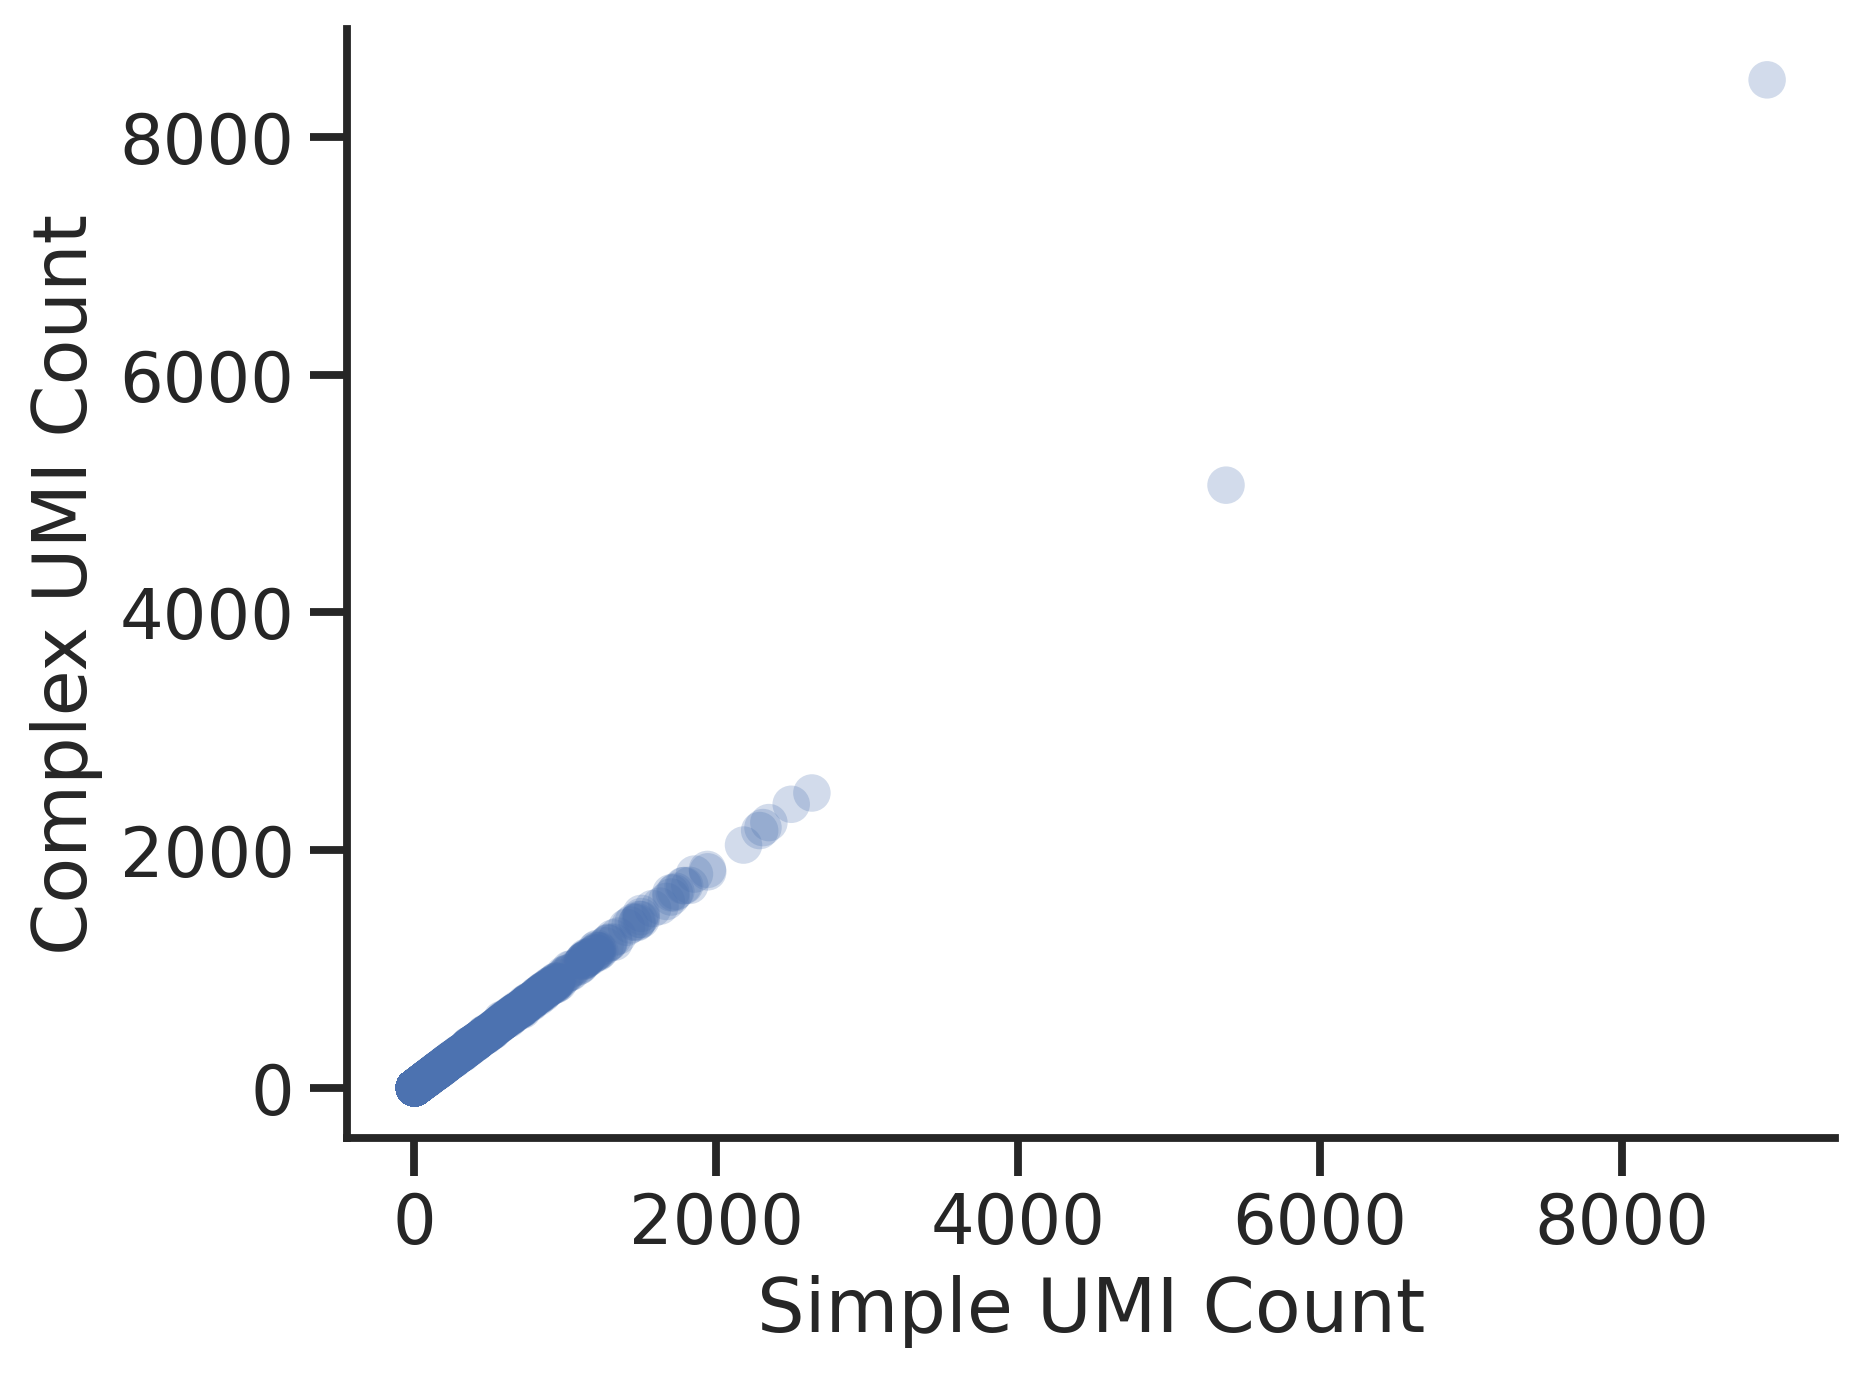

In [19]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.scatterplot(data = AD_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_directional", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Complex UMI Count")

Text(0, 0.5, 'Difference from\nComplex UMI Count')

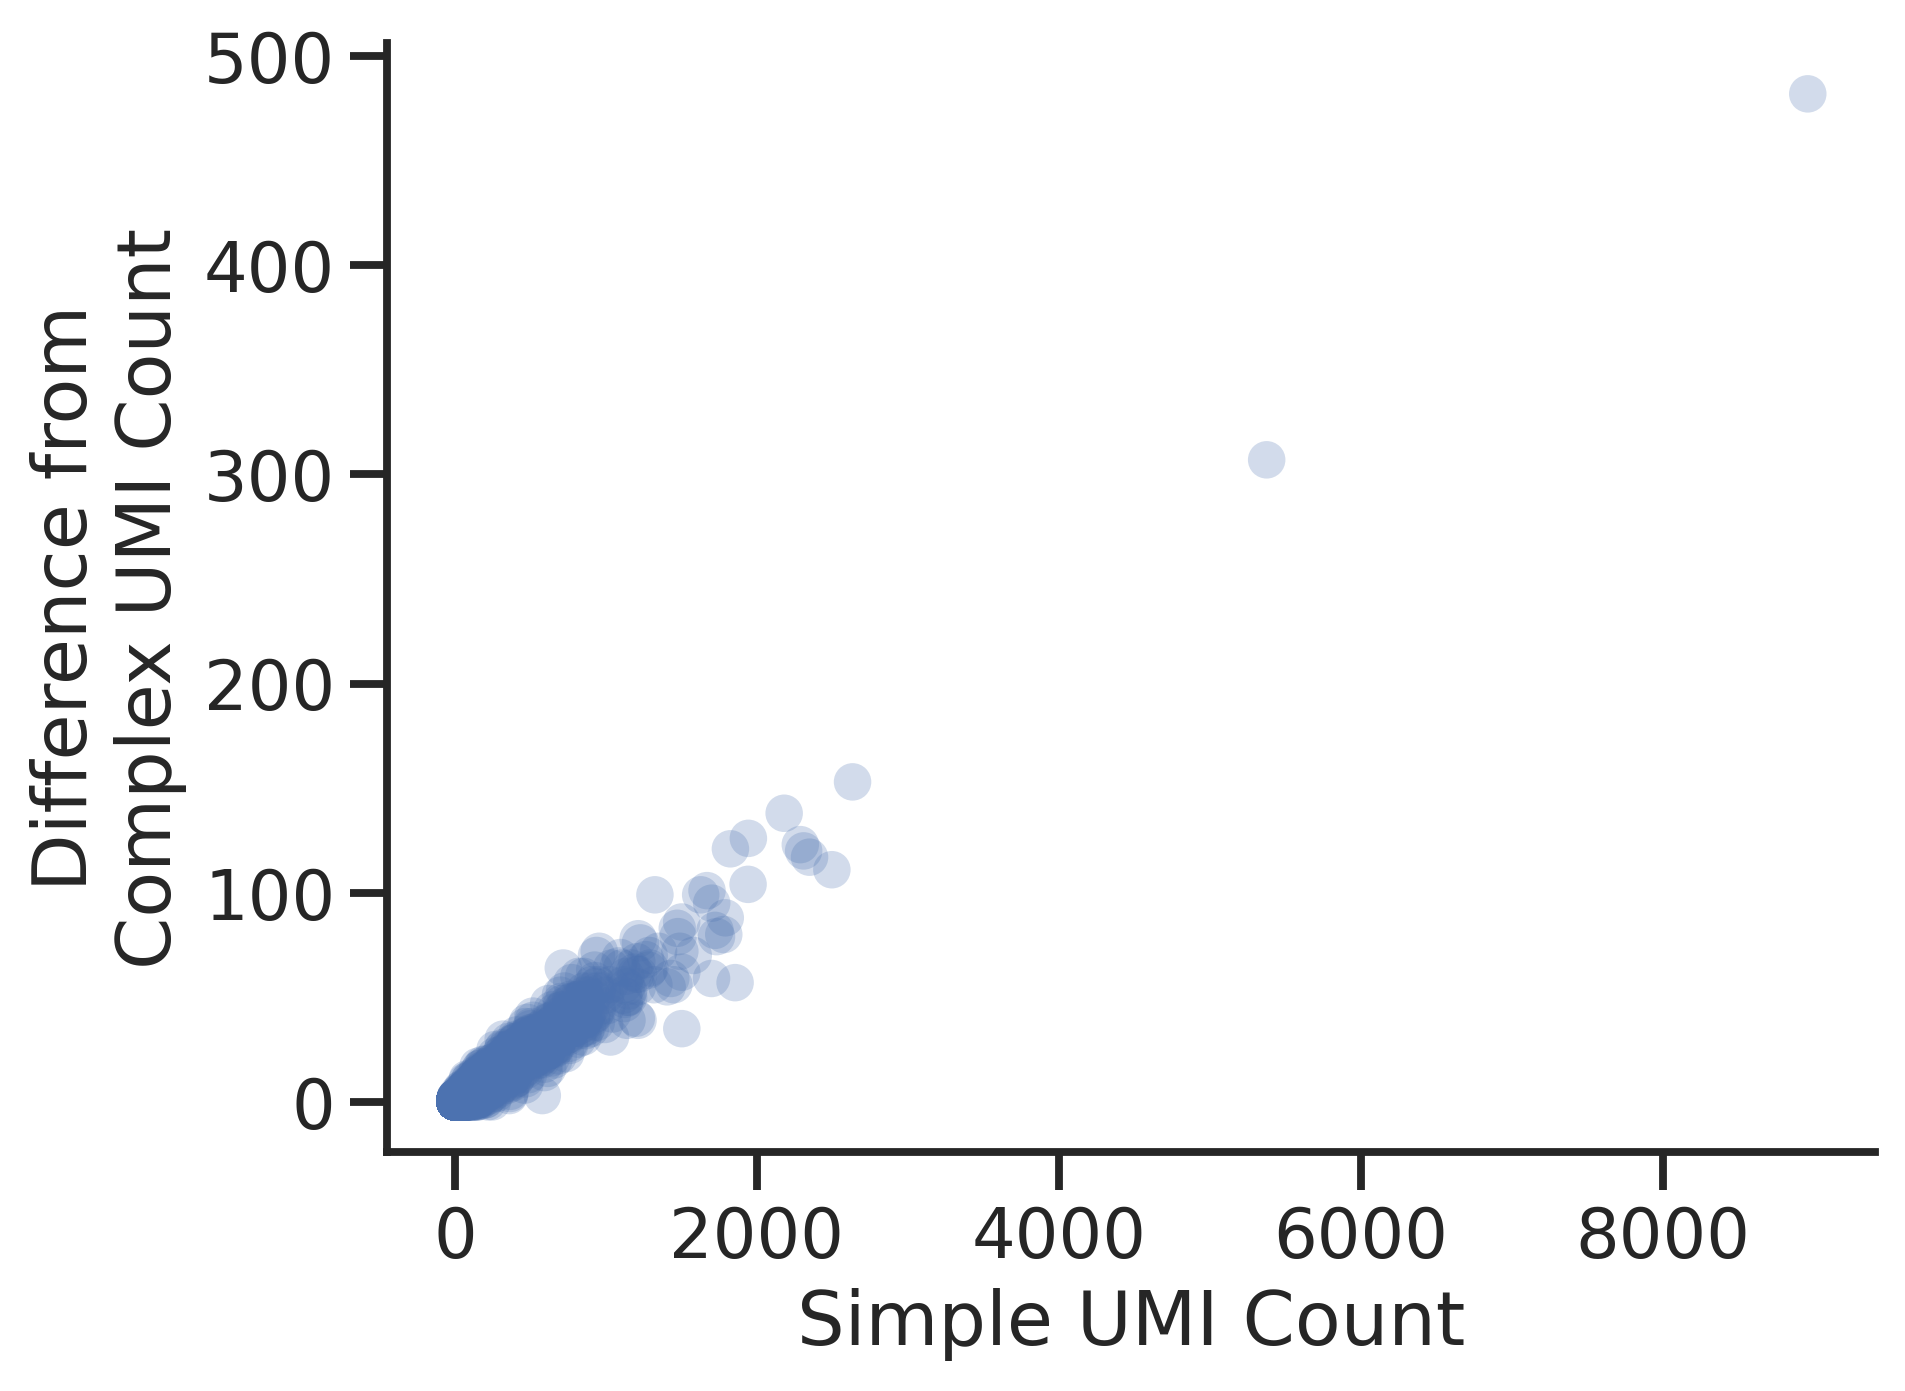

In [22]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)

sns.scatterplot(data = AD_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_diff", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Difference from\nComplex UMI Count")

# Get all RT Counts

In [14]:
# Reading in RT simple counts
con.execute("""
CREATE OR REPLACE TABLE RT_simple AS
SELECT
    RPTR_BC,
    count,
    regexp_extract(filename,'RPTR_(\\d+)_',1)::INT AS rep,
    regexp_extract(filename,'RPTR_\\d+_(\\d+)',1)::INT AS time,
    RPTR_BC AS gene
FROM read_csv_auto(
'../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*RPTR*/*simple*',
delim='\t',
filename=true
);
SELECT * FROM RT_simple LIMIT 5;
""").fetchdf()

,RPTR_BC,count,rep,time,gene
0,CCCTTGTTTCAATC,2395,1,0,CCCTTGTTTCAATC
1,AGTCGTGGTAAACT,2273,1,0,AGTCGTGGTAAACT
2,TTATGAAGACTGAT,1784,1,0,TTATGAAGACTGAT
3,GGAGGGGTCAGAAG,1648,1,0,GGAGGGGTCAGAAG
4,CGTTCAAAAACCAG,1591,1,0,CGTTCAAAAACCAG


In [12]:
# Reading in RT directional counts
con.execute("""
CREATE TABLE RT_directional AS
SELECT
    gene,
    count,
    regexp_extract(filename,'RPTR_(\\d+)_',1)::INT AS rep,
    regexp_extract(filename,'RPTR_\\d+_(\\d+)',1)::INT AS time
FROM read_csv_auto(
'../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*RPTR*/*directional*',
delim='\t',
filename=true
);
SELECT * FROM RT_directional LIMIT 5;
""").fetchdf()

,gene,count,rep,time
0,AAAAAAAAAAAAAA,2,1,0
1,AAAAAAAAAAAACT,1,1,0
2,AAAAAAAAAAACAA,4,1,0
3,AAAAAAAAAAACAC,3,1,0
4,AAAAAAAAAAACCA,1,1,0


In [17]:
# merge RT results
con.execute("""
CREATE TABLE merged_RT AS
SELECT
    s.RPTR_BC,
    s.rep,
    s.time,
    s.count AS count_simple,
    d.count AS count_directional,
    s.gene
FROM RT_simple s
JOIN RT_directional d
USING (gene, rep, time);
SELECT * FROM merged_RT LIMIT 5;
""").fetchdf()

,RPTR_BC,rep,time,count_simple,count_directional,gene
0,TCATAACTCAGGAG,1,0,1,1,TCATAACTCAGGAG
1,AGAGCGTGGGTTGG,1,0,1,1,AGAGCGTGGGTTGG
2,GTGTAAGGGGTGGT,1,0,1,1,GTGTAAGGGGTGGT
3,CGCGATTCGAGTCC,1,0,1,1,CGCGATTCGAGTCC
4,TCAGACTCGGTAAC,1,0,1,1,TCAGACTCGGTAAC


In [23]:
RT_merged_counts_only = con.execute("SELECT count_simple, count_directional FROM merged_RT").fetchdf()
RT_merged_counts_only["count_diff"] = RT_merged_counts_only["count_simple"] - RT_merged_counts_only["count_directional"]
RT_merged_counts_only

,count_simple,count_directional,count_diff
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
...,...,...,...
50285139,1,1,0
50285140,1,1,0
50285141,1,1,0
50285142,1,1,0


Text(0, 0.5, 'Complex UMI Count')

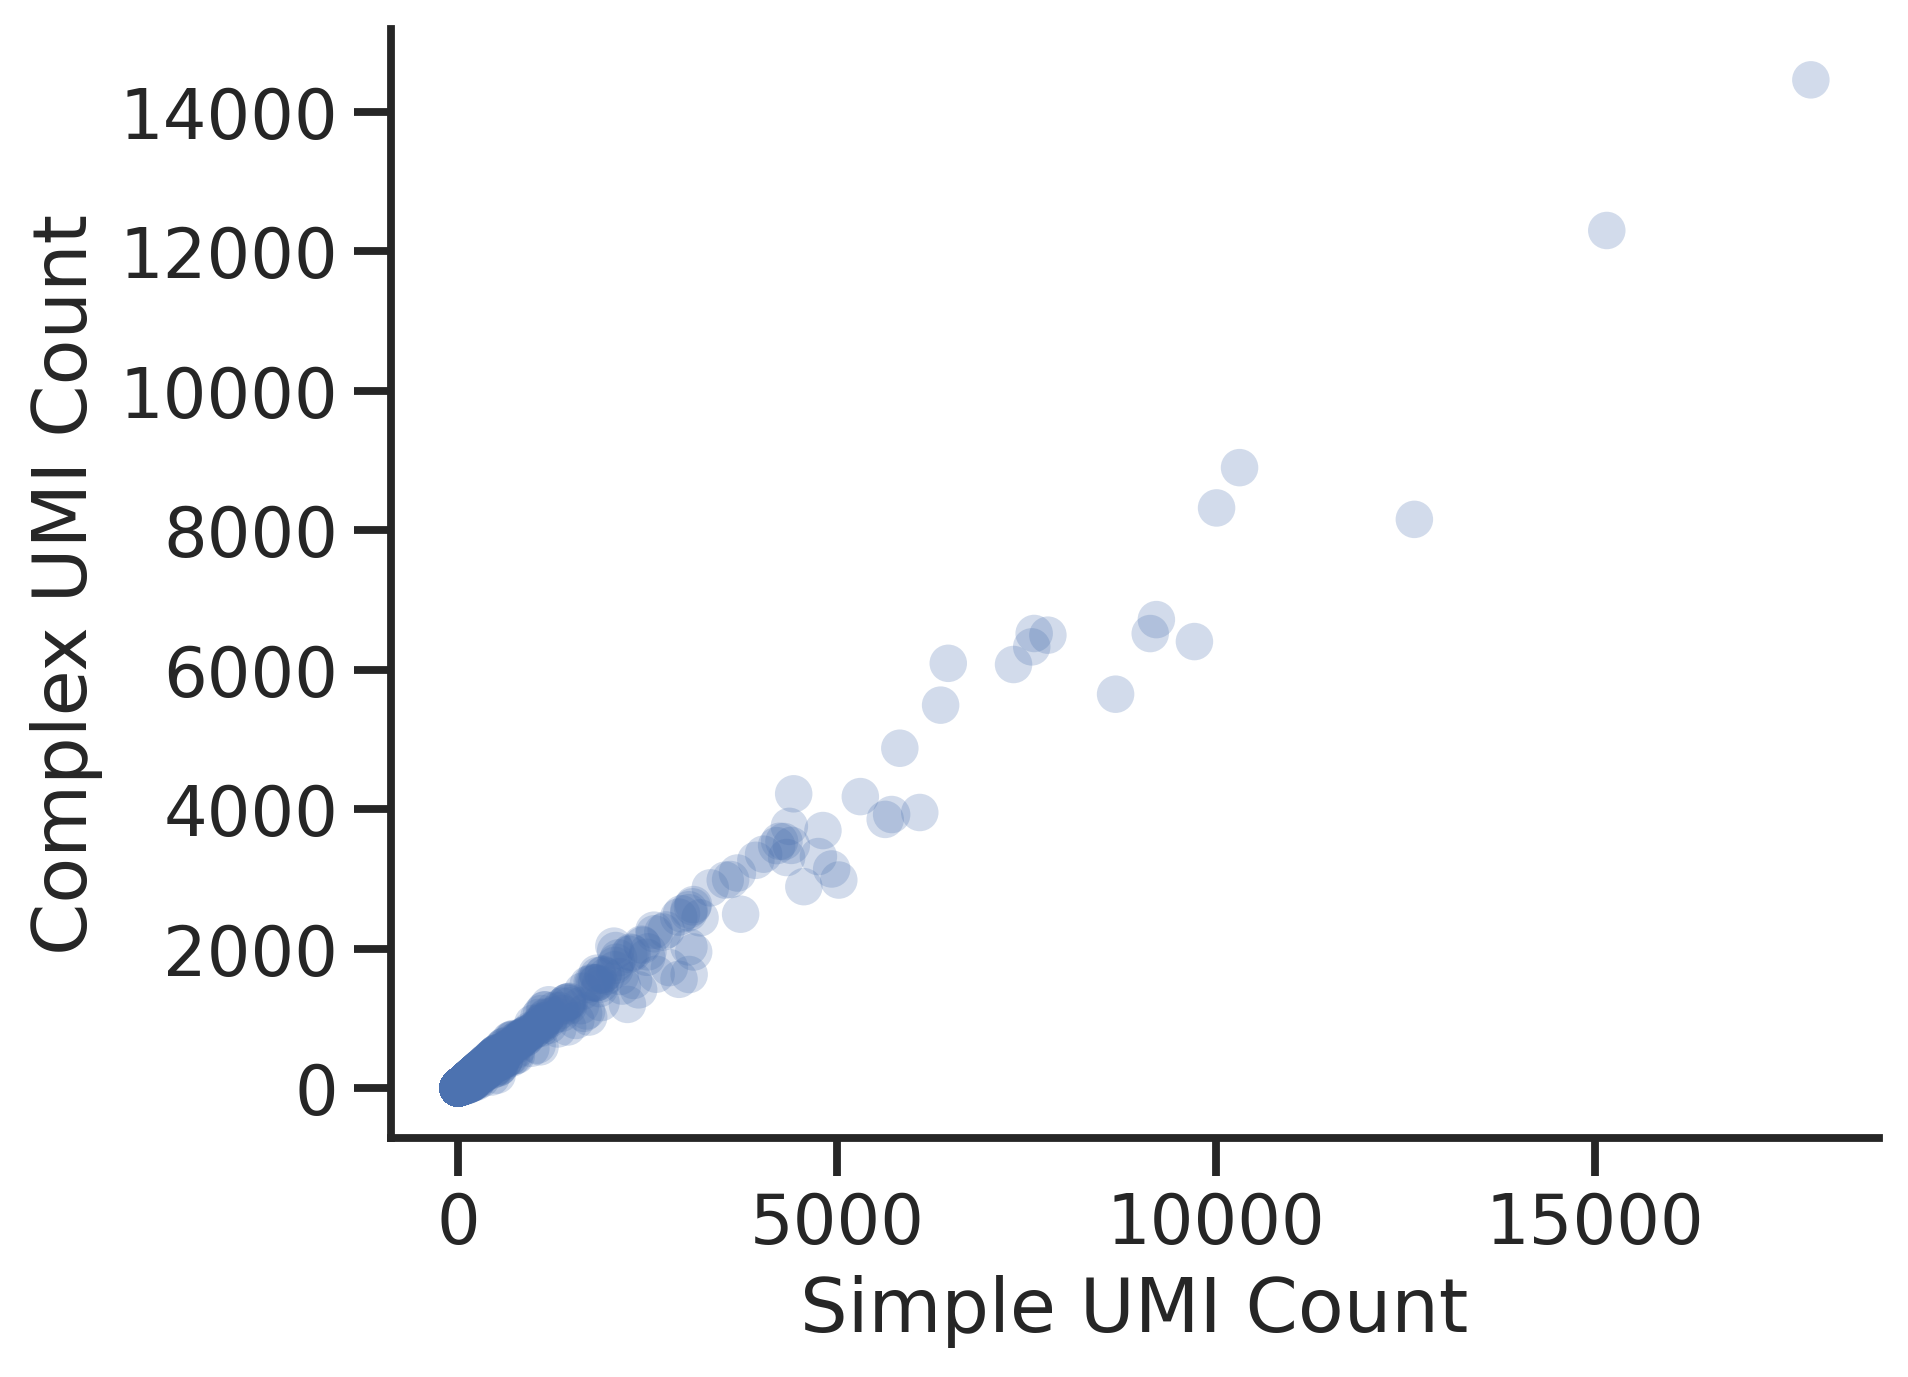

In [24]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.scatterplot(data = RT_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_directional", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Complex UMI Count")

Text(0, 0.5, 'Difference from\nComplex UMI Count')

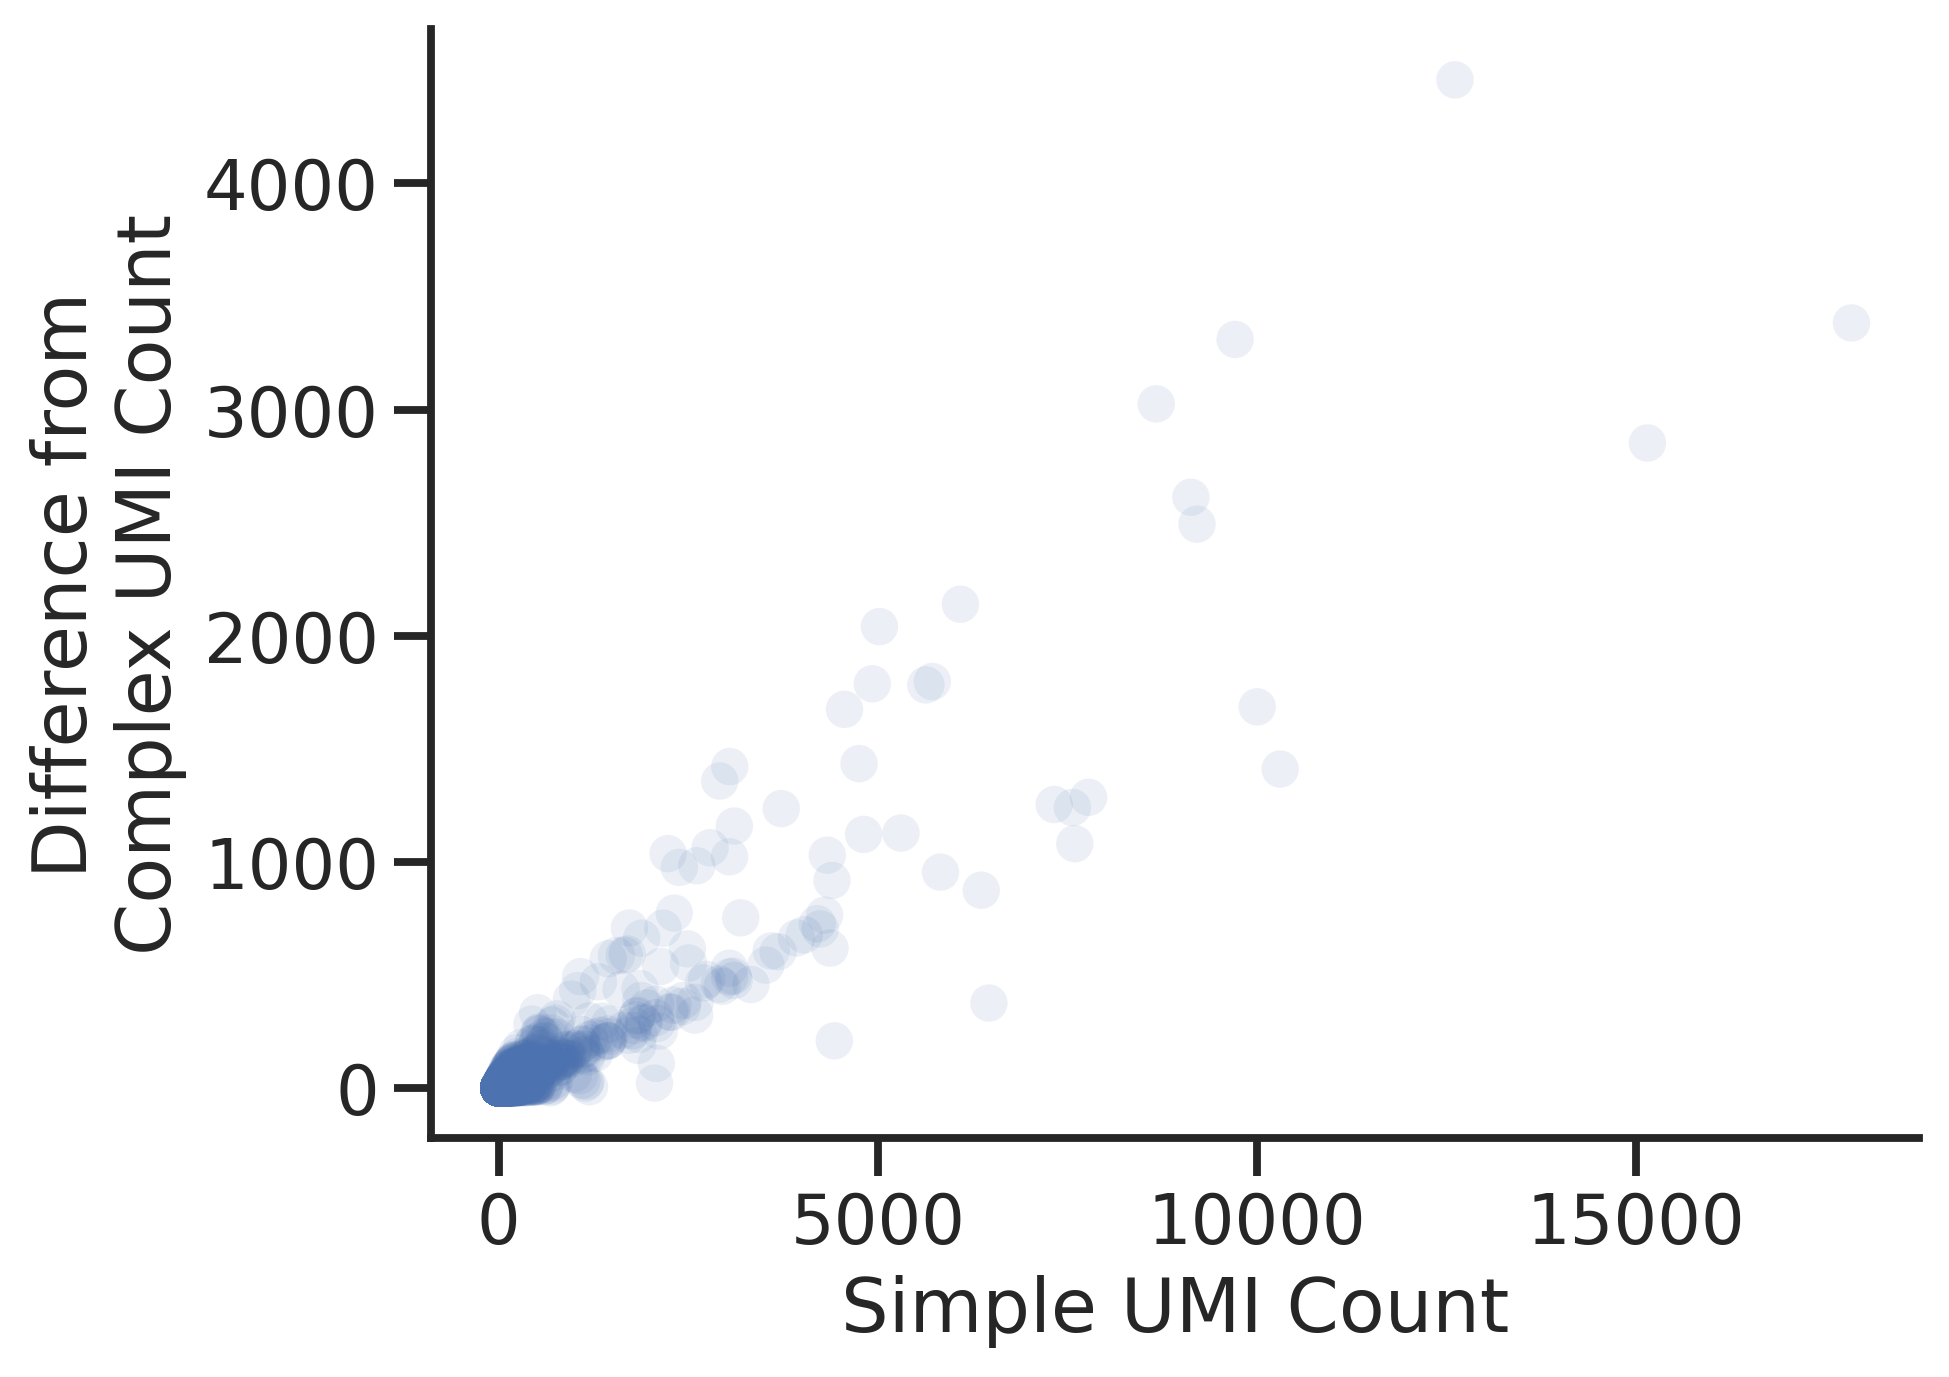

In [25]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)

sns.scatterplot(data = RT_merged_counts_only.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_diff", 
                edgecolor = 'none',
               alpha = 0.1)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Difference from\nComplex UMI Count")

# Merging with step 1

In [27]:
# Merge AD results with step 1
con.execute("""
CREATE TABLE step1_map_AD AS
SELECT
    s.*,
    a.count_simple,
    a.count_directional,
    a.rep,
    a.time
FROM step1_map s
JOIN AD_merged a
ON s.AD = a.AD
AND s.AD_BC = a.AD_BC;
SELECT * FROM step1_map_AD LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC,count_simple,count_directional,rep,time
0,GGTTTGCCAGAAACTCAATCTTCTTTGGGTCCAGATGCTACTGCTT...,AGGTTATTAAT,TGATCAGACTTTGA,78,69,3,5
1,TTGTCTAAATCTCCATCTCCATTTGACTTTGGTGCTGCTCCACCAG...,TTAAGTTTCGC,GCACCCGGAAAGTG,78,75,3,5
2,TCTCCATTTATTAATGATTCATTTGAATGTTCTCCAATGTTTAATG...,TCCCAGGGAGG,CGGGAGTCCGTTGT,78,73,3,5
3,TCTGCTCAATCTTTGCAGAATCAAAGAGTTGCTGCTATTATTCAAT...,TTTTTTAGTGG,TACTTGCTATTGCT,78,76,3,5
4,TCTACTAATTCTCCACCATCTGGTAGACATTCTTCTGTTTCTGGTG...,AGAGCACCCAG,TCGCGGAAAGGAAA,78,72,3,5


In [28]:
# Merge RT results with step 1
con.execute("""
CREATE TABLE step1_map_RT AS
SELECT
    s.*,
    r.count_simple,
    r.count_directional,
    r.rep,
    r.time
FROM step1_map s
JOIN merged_RT r
ON s.RPTR_BC = r.RPTR_BC;
SELECT * FROM step1_map_AD LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC,count_simple,count_directional,rep,time
0,GGTTTGCCAGAAACTCAATCTTCTTTGGGTCCAGATGCTACTGCTT...,AGGTTATTAAT,TGATCAGACTTTGA,78,69,3,5
1,TTGTCTAAATCTCCATCTCCATTTGACTTTGGTGCTGCTCCACCAG...,TTAAGTTTCGC,GCACCCGGAAAGTG,78,75,3,5
2,TCTCCATTTATTAATGATTCATTTGAATGTTCTCCAATGTTTAATG...,TCCCAGGGAGG,CGGGAGTCCGTTGT,78,73,3,5
3,TCTGCTCAATCTTTGCAGAATCAAAGAGTTGCTGCTATTATTCAAT...,TTTTTTAGTGG,TACTTGCTATTGCT,78,76,3,5
4,TCTACTAATTCTCCACCATCTGGTAGACATTCTTCTGTTTCTGGTG...,AGAGCACCCAG,TCGCGGAAAGGAAA,78,72,3,5


In [31]:
con.execute("""
CREATE TABLE AD_RT_merged AS
SELECT
    a.AD,
    a.AD_BC,
    a.RPTR_BC,
    a.rep,
    a.time,

    a.count_simple AS count_simple_AD,
    a.count_directional AS count_directional_AD,

    r.count_simple AS count_simple_RT,
    r.count_directional AS count_directional_RT

FROM step1_map_AD a
JOIN step1_map_RT r
USING (AD, AD_BC, RPTR_BC, rep, time);

SELECT * FROM AD_RT_merged LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8


In [32]:
# Calculate activity
con.execute("""
CREATE TABLE activity AS
SELECT *,
    count_simple_RT / count_simple_AD AS activity_simple,
    count_directional_RT / count_directional_AD AS activity_directional
FROM AD_RT_merged
WHERE
count_simple_AD IS NOT NULL
AND count_simple_RT IS NOT NULL;

SELECT * FROM activity LIMIT 5;

""").fetchdf()

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,0.754717,0.520408
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,0.056604,0.048544
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,0.113208,0.077670
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,0.066038,0.058824
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,0.094340,0.080000


In [34]:
AD_RT_merged = con.execute("SELECT * FROM activity").df()
AD_RT_merged.to_csv("../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_results_per_barcode.csv")

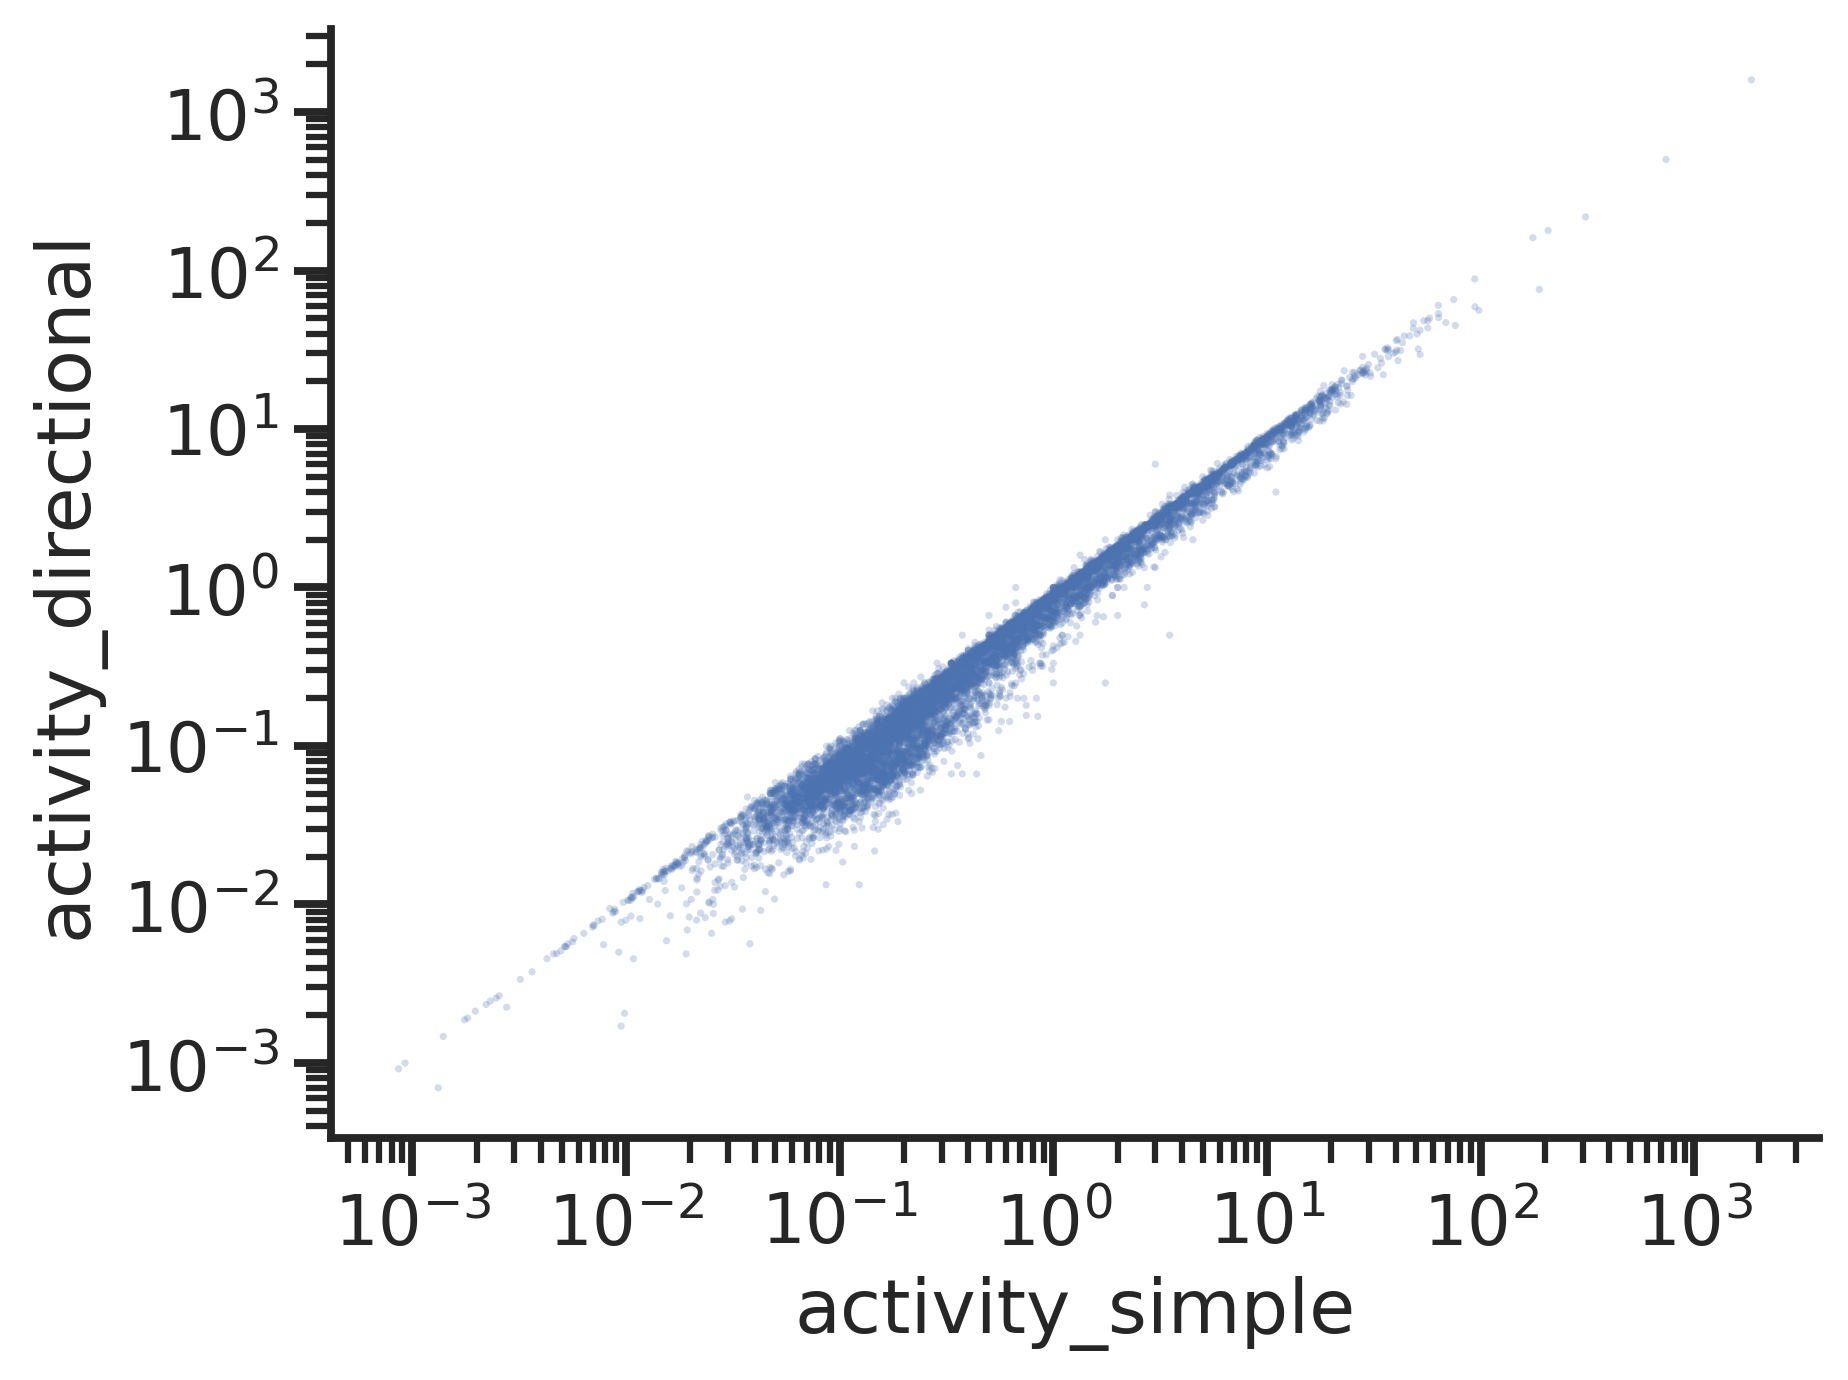

In [36]:
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)

sns.scatterplot(
    data=AD_RT_merged.sample(10000, random_state=44),
    x="activity_simple",
    y="activity_directional",
    edgecolor='none',
    alpha=0.25,
    s=3
)

plt.xscale("log")
plt.yscale("log")

sns.despine()

# Comparing with Emily's data

In [37]:
activity_comparison = pd.read_csv("../../output/GCN4_sk_vs_ec_activities.csv")
activity_comparison

,Unnamed: 0,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
0,0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,3,5,646,402,0.622291,1,403,403.000000
1,1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,3,5,806,2784,3.454094,806,2779,3.447891
2,2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,3,5,657,1349,2.053272,660,1362,2.063636
3,3,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,3,5,917,690,0.752454,920,679,0.738043
4,4,CAAAGACCAACTAGACCACAAGTTCCATTGTTCTCTCAATCTACTG...,GCCCTTGTATT,TTAGTATTTTATCT,3,5,533,140,0.262664,534,139,0.260300
...,...,...,...,...,...,...,...,...,...,...,...,...
296868,296868,ACTTCTGCTTCTTCTGCTTCTCAAATTGTTGTTCATCCAGGTGGTG...,GCCCCCCGTTG,TATGTAATTAACCT,1,240,9,12,1.333333,9,12,1.333333
296869,296869,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,1,240,57,13,0.228070,56,13,0.232143
296870,296870,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,1,240,53,3,0.056604,53,3,0.056604
296871,296871,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,1,240,536,1,0.001866,536,670,1.250000


In [46]:
merged_activities = pd.merge(activity_comparison[["AD", "AD_BC", "RPTR_BC", "EC_AD_umi_count", "EC_RT_umi_count", "rep", "time", "EC_activity"]], 
                             AD_RT_merged[["AD", "AD_BC","count_directional_AD", "count_directional_RT", "RPTR_BC", "rep", "time", "activity_directional"]])
merged_activities

,AD,AD_BC,RPTR_BC,EC_AD_umi_count,EC_RT_umi_count,rep,time,EC_activity,count_directional_AD,count_directional_RT,activity_directional
0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,646,402,3,5,0.622291,617,233,0.377634
1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,806,2784,3,5,3.454094,777,1716,2.208494
2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,657,1349,3,5,2.053272,630,776,1.231746
3,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,917,690,3,5,0.752454,871,405,0.464983
4,CAAAGACCAACTAGACCACAAGTTCCATTGTTCTCTCAATCTACTG...,GCCCTTGTATT,TTAGTATTTTATCT,533,140,3,5,0.262664,508,86,0.169291
...,...,...,...,...,...,...,...,...,...,...,...
296539,ACTTCTGCTTCTTCTGCTTCTCAAATTGTTGTTCATCCAGGTGGTG...,GCCCCCCGTTG,TATGTAATTAACCT,9,12,1,240,1.333333,8,11,1.375000
296540,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,57,13,1,240,0.228070,55,10,0.181818
296541,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,53,3,1,240,0.056604,51,3,0.058824
296542,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,536,1,1,240,0.001866,514,557,1.083658


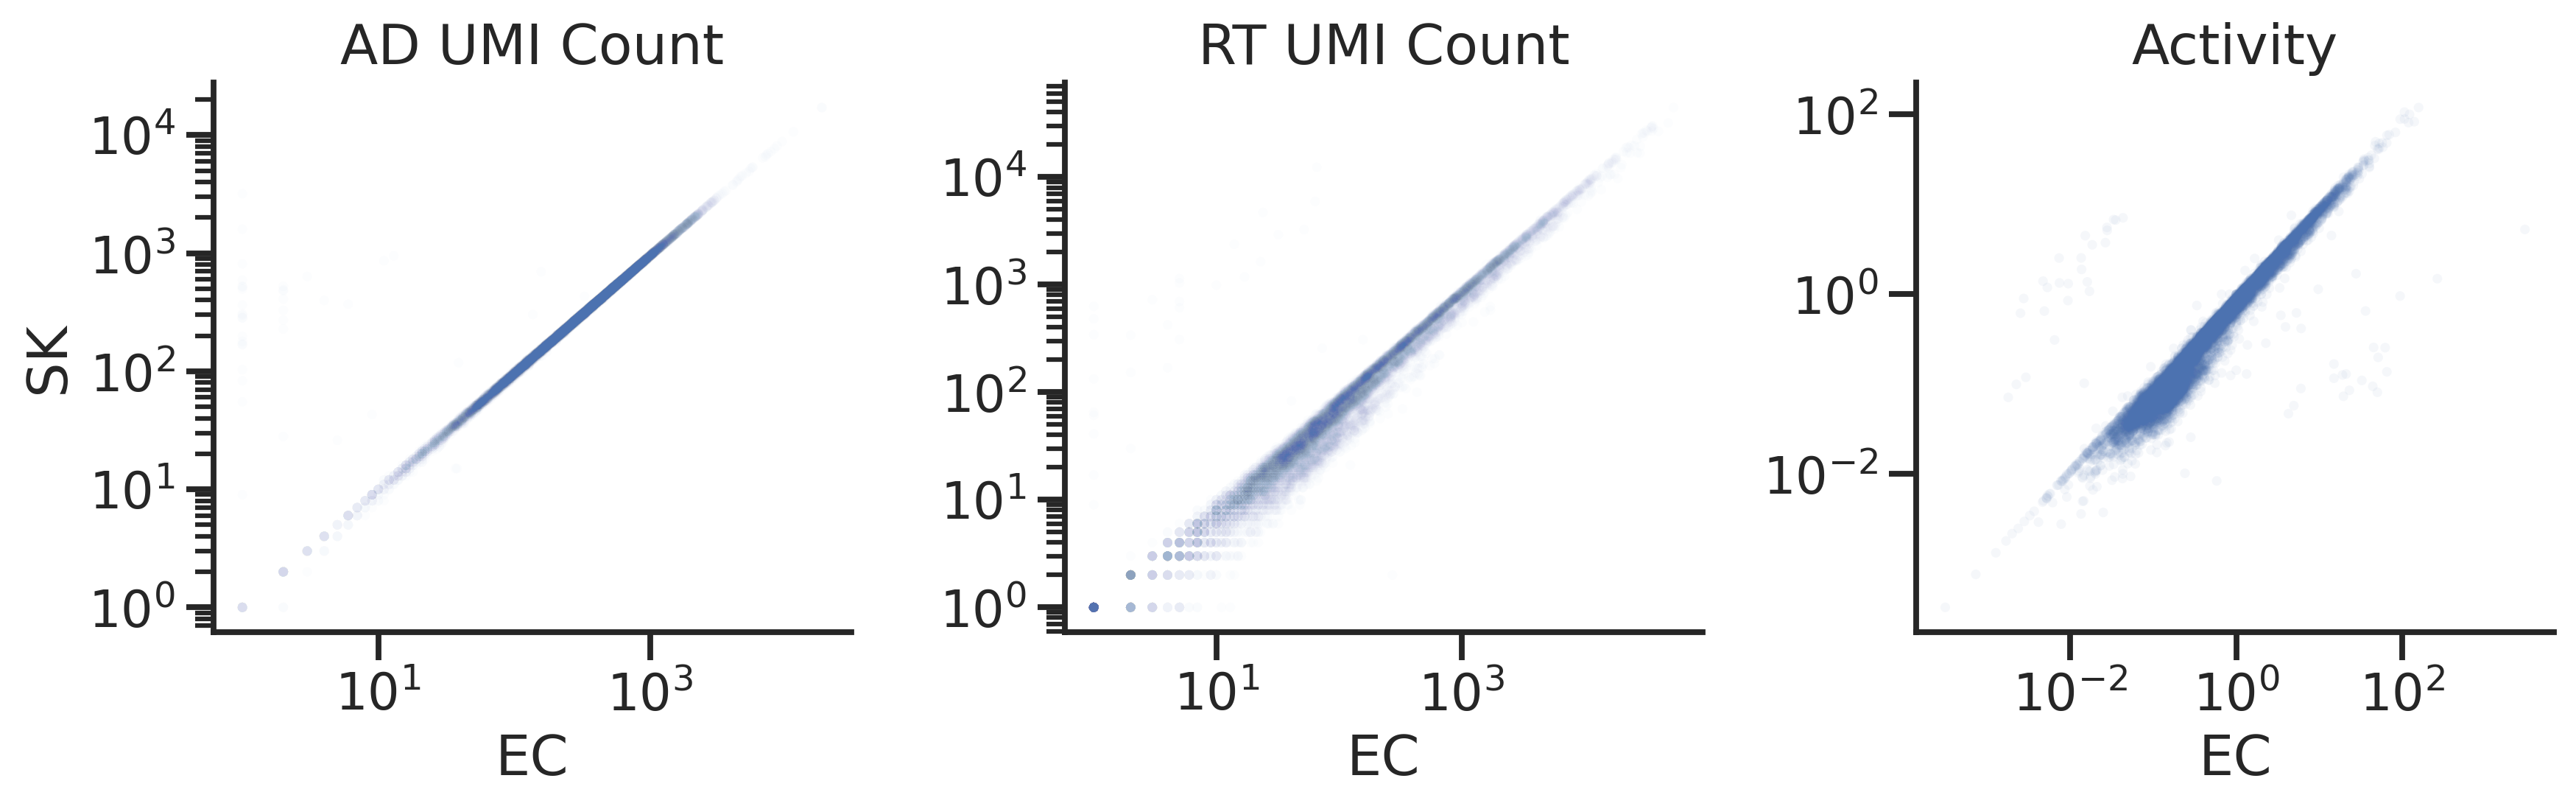

In [60]:
fig, axs = plt.subplots(1,3, figsize = (12,4), dpi = 300)

ax = axs[0]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_AD_umi_count", y = "count_directional_AD", alpha = 0.01, edgecolor = 'none', s = 10, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[0].set_ylabel("SK")
axs[0].set_title("AD UMI Count")
axs[0].set_xlabel("EC")

ax = axs[1]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_RT_umi_count", y = "count_directional_RT", alpha = 0.01, edgecolor = 'none', s = 10, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[1].set_ylabel("")
axs[1].set_title("RT UMI Count")
axs[1].set_xlabel("EC")

ax = axs[2]
sns.scatterplot(data = merged_activities.sample(10000), x = "EC_activity", y = "activity_directional", edgecolor = 'none', s = 10, alpha = 0.05, ax = ax)
ax.set_xscale('log')
ax.set_yscale('log')
axs[2].set_ylabel("")
axs[2].set_title("Activity")
axs[2].set_xlabel("EC")

plt.tight_layout()

sns.despine()